<a href="https://colab.research.google.com/github/AmitabhDey-byte/Project3/blob/main/gdg_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np
import seaborn as sea
import pandas as pd
import matplotlib.pyplot as plt

sea.set_theme(style="darkgrid", palette="Set3")

In [41]:
ingest = pd.read_csv("/content/sample_data/NetFlix.csv")

df = ingest.loc[:, ~ingest.columns.str.contains('^Unnamed')]

df = df[df['cast'] != 'Unknown'] #i need to make this because there were some unknown values in the cast column, found it in the 8th visualization so what it does it simply remove the rows which have unknown value



In [42]:
#checking null values
df.isnull().any()

,0
show_id,False
type,False
title,False
director,True
cast,True
country,True
date_added,True
release_year,False
rating,True
duration,False


In [43]:
#checking for any duplicate

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [44]:
#data summary after cleaning and removing 'unnamed' and 'unknown' data values

df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


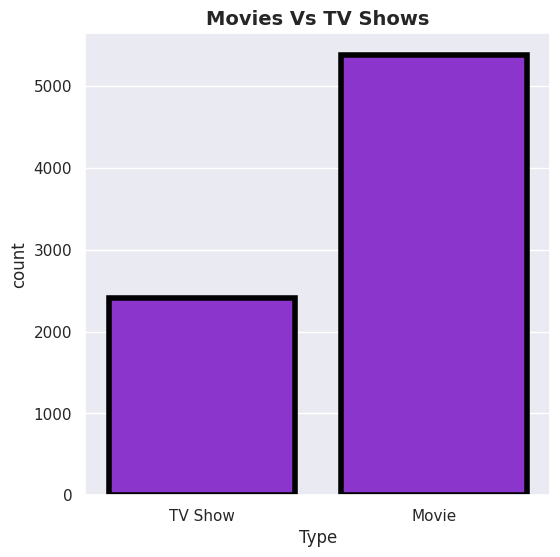

In [45]:
#fist visualiztion (Movie and TV Shows)

plt.figure(figsize=(6,6))
sea.countplot(x='type', data=df, linewidth=4, color='#8e1ce6', edgecolor='black')

plt.title("Movies Vs TV Shows", fontsize=14, weight='bold')
plt.xlabel("Type")
plt.ylabel("count")
plt.show()

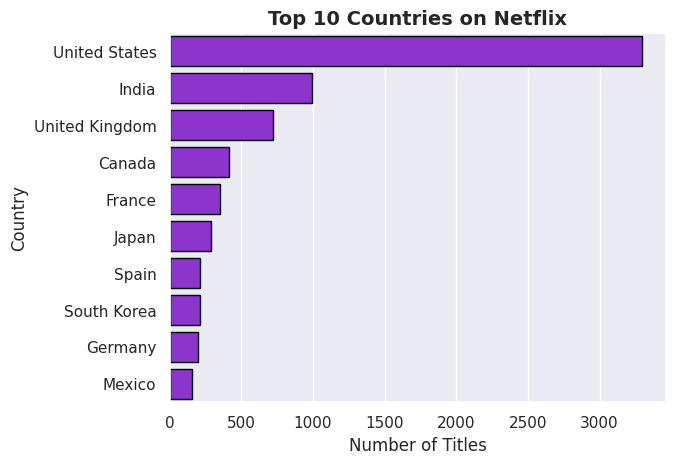

In [46]:
#2nd Visualization Content by Country -- konse country ka kitna content

country_counting = df['country'].str.split(', ').explode().value_counts().head(10)

sea.barplot(x=country_counting.values, y=country_counting.index, color='#8e1ce6', edgecolor='black')

plt.title("Top 10 Countries on Netflix", fontsize=14, weight='bold')
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

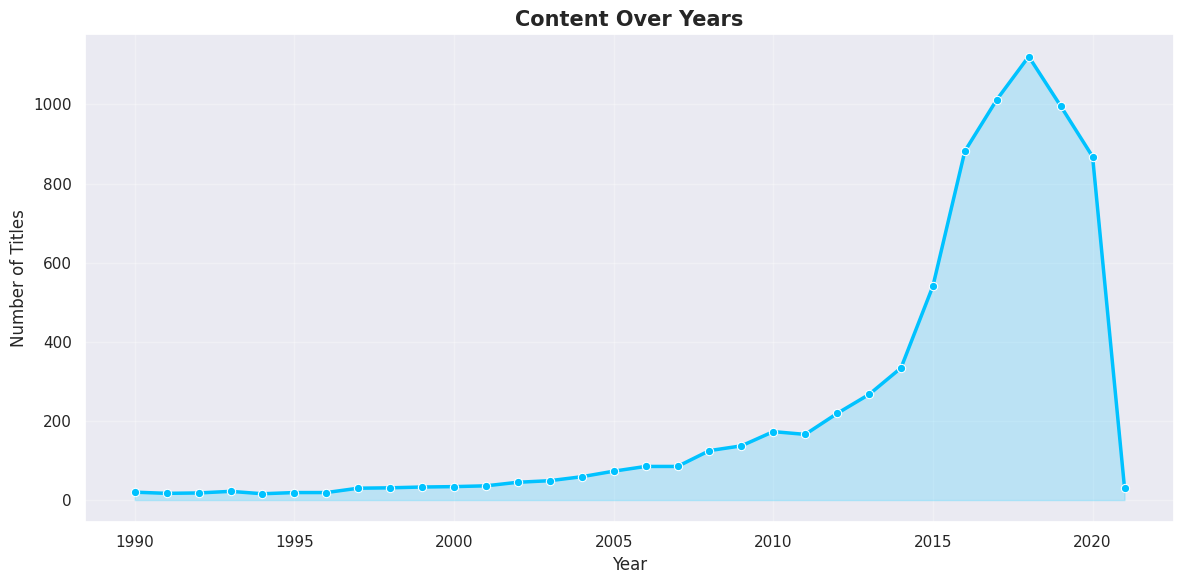

In [47]:
#3rd Visualizition :content over years

year_counting = df['release_year'].value_counts().sort_index()
years = np.arange(1990, year_counting.index.max() + 1)

year_counting = year_counting.reindex(years, fill_value=0)
plt.figure(figsize=(12,6))

sea.lineplot(x=year_counting.index,y=year_counting.values,marker='o',linewidth=2.5, color='#00c2ff')

plt.fill_between(year_counting.index, year_counting.values, alpha=0.2, color='#00c2ff')

plt.title("Content Over Years", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

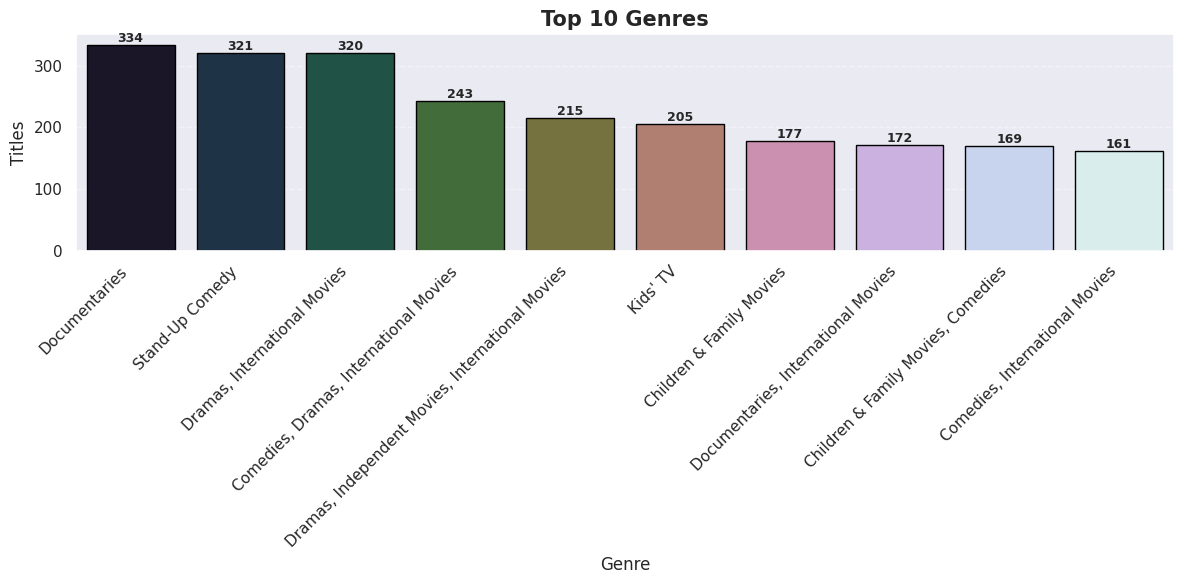

In [48]:
#4th Visualization : Most popular genres-- categories

genre_counting = df [ 'genres'].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sea.barplot(x=genre_counting.index,y=genre_counting.values,palette='cubehelix',hue=genre_counting.index,edgecolor='black')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',va='bottom',fontsize=9,weight='bold')

plt.title("Top 10 Genres", fontsize=15, weight='bold')
plt.xlabel("Genre")
plt.ylabel("Titles")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

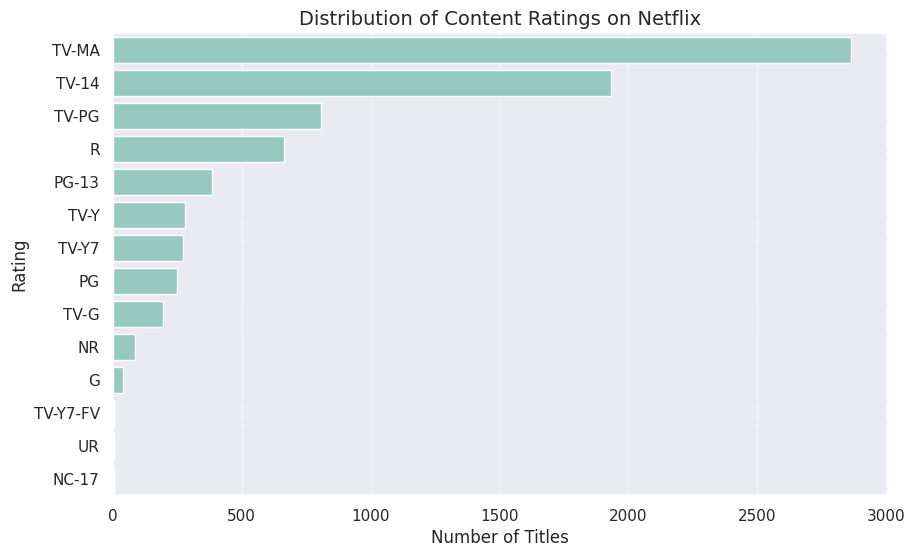

In [49]:
#5th Visualization :Rating Distribution-- like ADULT oriented h ya cool for everyon

plt.figure(figsize=(10,6))
sea.countplot(y='rating',data=df,order=df['rating'].value_counts().index)

plt.title("Distribution of Content Ratings on Netflix", fontsize=14, )
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

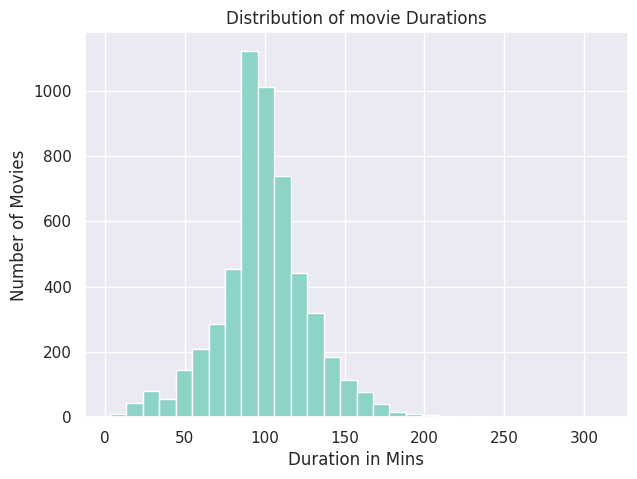

In [50]:
#6th Visualization: Movie Durations

movies = df[df['type'] == 'Movie'].copy()

plt.figure(figsize=(7,5))
plt.hist(movies['duration'], bins=30)

plt.title("Distribution of movie Durations")
plt.xlabel("Duration in Mins")
plt.ylabel("Number of Movies")

plt.show()

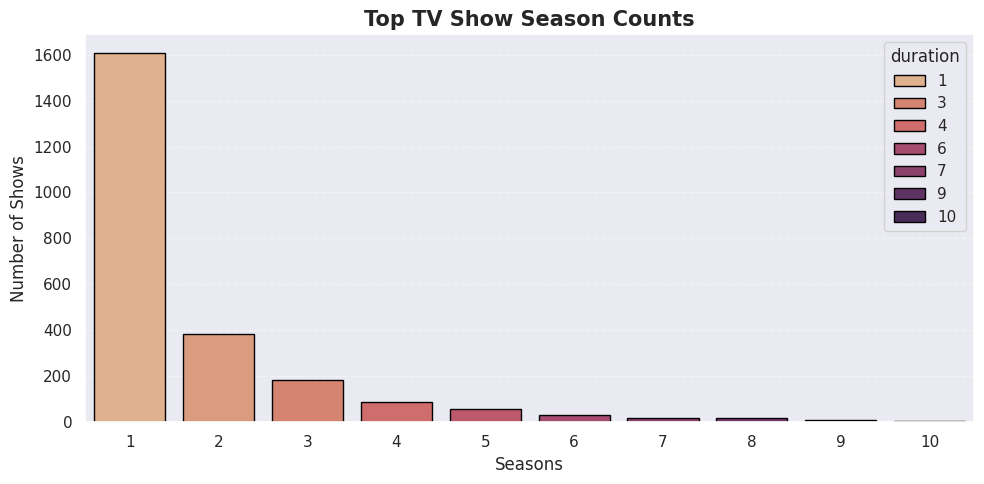

In [51]:
#7th Visualization: no os seasons in tv shows

tv = df[df['type'] == 'TV Show'].copy()

plt.figure(figsize=(10,5))

tv_counts = tv['duration'].value_counts().head(10)

ax =sea.barplot(x=tv_counts.index,y=tv_counts.values,palette='flare',hue=tv_counts.index,edgecolor='black')

plt.title("Top TV Show Season Counts", fontsize=15, weight='bold')
plt.xlabel("Seasons")
plt.ylabel("Number of Shows")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



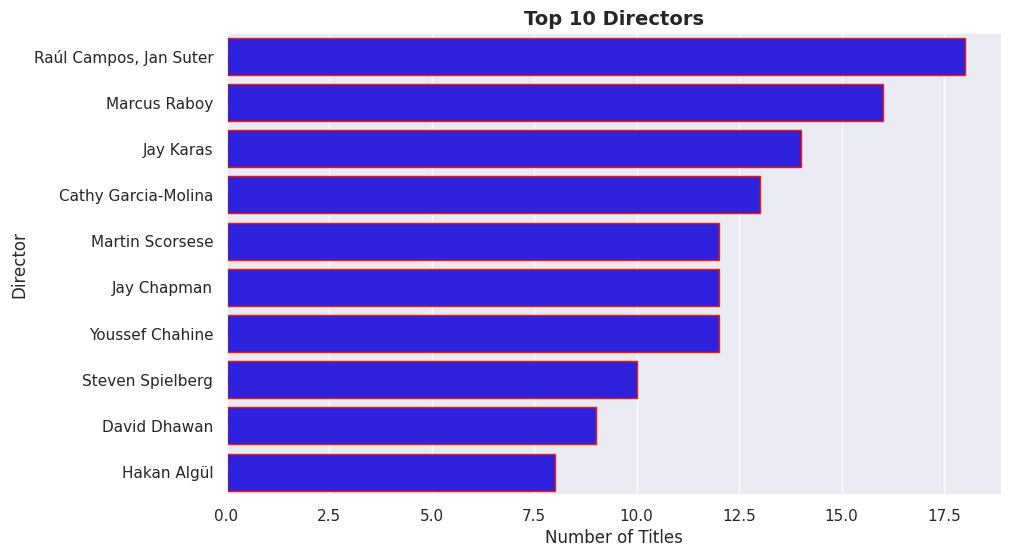

In [52]:
#8 top directors

director_counts = df['director'].value_counts().head(10)

plt.figure(figsize=(10,6))
sea.barplot(x=director_counts.values, y=director_counts.index,color='#1303fc',edgecolor='#fc1703')

plt.title("Top 10 Directors", fontsize=14, weight='bold')
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

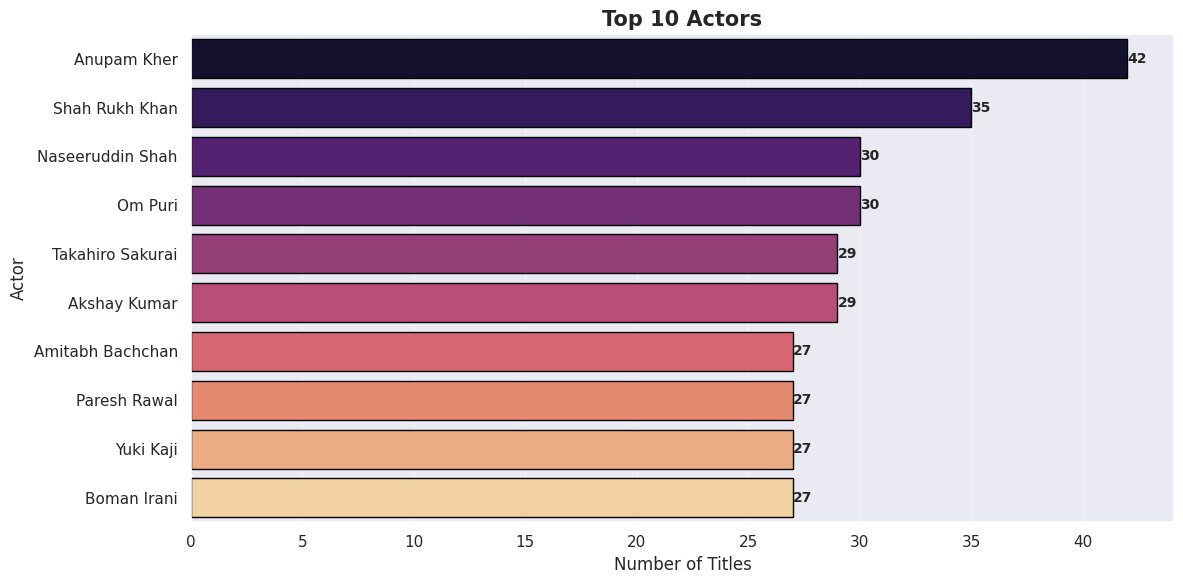

In [53]:
#9th top actors
actor_counts = df['cast'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sea.barplot(x=actor_counts.values,y=actor_counts.index,hue=actor_counts.index,palette='magma',edgecolor='black')

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',va='center',fontsize=10,weight='bold')

plt.title("Top 10 Actors", fontsize=15, weight='bold')
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Actor", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

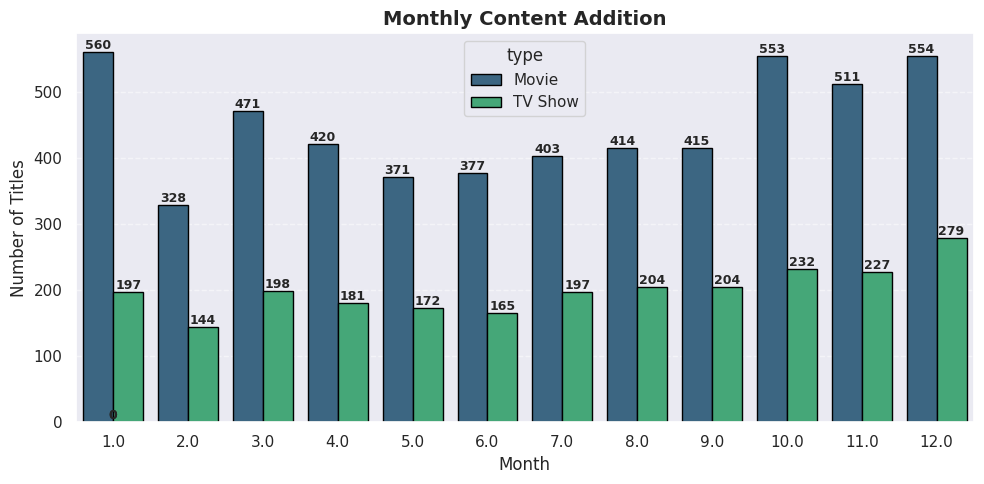

In [59]:
#10th avg monthly content added

df['date_added'] = pd.to_datetime(df['date_added'])
df['month'] = df['date_added'].dt.month

plt.figure(figsize=(10,5))

ax = sea.countplot(x='month',data=df,palette='viridis',hue='type',edgecolor='black')
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', #using the height as count value
        (p.get_x() + p.get_width()/2., p.get_height()),#this i used to exactly align the text or the count value in the middle of the bars
        ha='center',va='bottom',fontsize=9,weight='bold')

plt.title("Monthly Content Addition", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

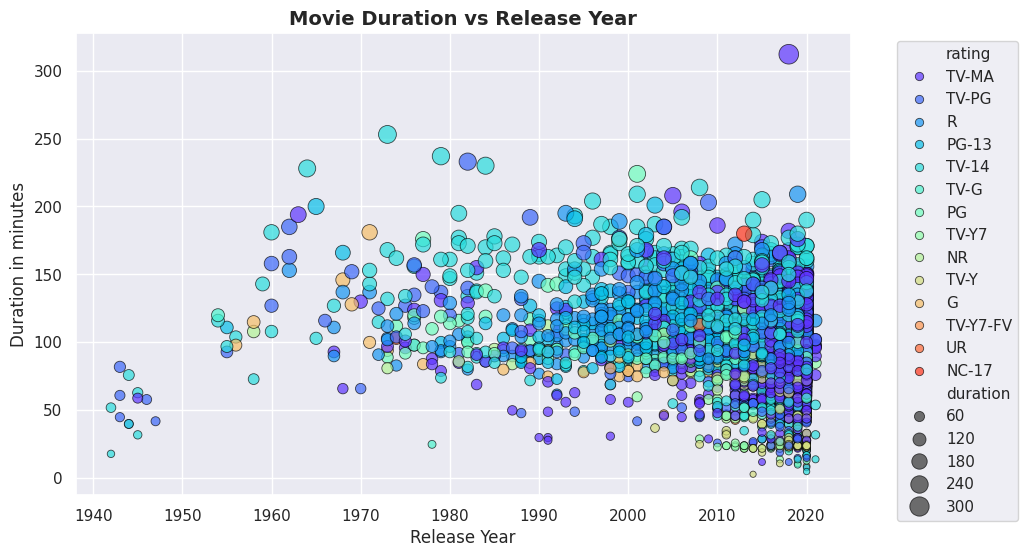

In [55]:
#11 just a normal movie vs year trend - coz i kinda wanna have one scatterplot

movies = df[df['type'] == 'Movie'].copy()
movies['duration'] = movies['duration'].astype(float)

plt.figure(figsize=(10,6))
sea.scatterplot(x='release_year',y='duration',data=movies,hue='rating',size='duration',sizes=(20,200),
    palette='rainbow',alpha=0.7,edgecolor='black')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("Movie Duration vs Release Year", fontsize=14, weight='bold')
plt.xlabel("Release Year")
plt.ylabel("Duration in minutes")

plt.show()

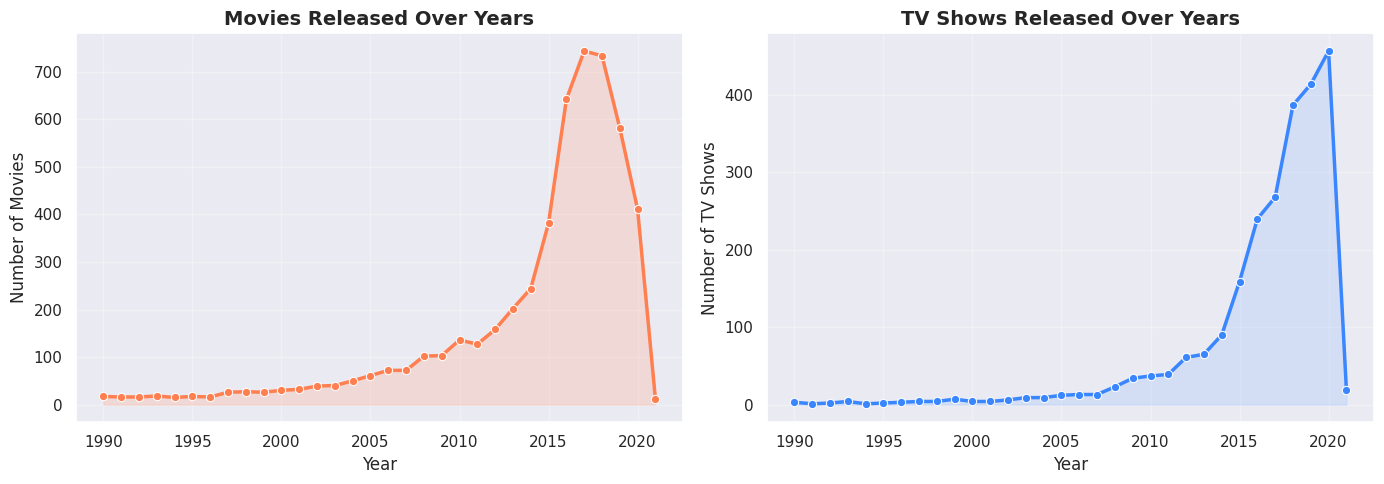

In [56]:
#12th Visualization: no os seasons in tv shows - it was basically 7th visualization at first
#unfortunately while writing the codes in different cells and adding new visualization
#it was left out so writing at last
tv = df[df['type'] == 'TV Show'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

movie_year = df[df['type']=='Movie']['release_year'].value_counts().sort_index()
tv_year = df[df['type']=='TV Show']['release_year'].value_counts().sort_index()

years = np.arange(1990, max(movie_year.index.max(), tv_year.index.max()) + 1)

movie_year = movie_year.reindex(years, fill_value=0)
tv_year = tv_year.reindex(years, fill_value=0)

sea.lineplot(x=movie_year.index, y=movie_year.values,ax=axes[0], marker='o',linewidth=2.5,color='#ff7f50')
axes[0].fill_between(movie_year.index, movie_year.values, color='#ffb199', alpha=0.3)

axes[0].set_title("Movies Released Over Years", fontsize=14, weight='bold')
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Movies")
axes[0].grid(alpha=0.3)


sea.lineplot(x=tv_year.index,y=tv_year.values,ax=axes[1], marker='o',linewidth=2.5,color='#3a86ff')

axes[1].fill_between(tv_year.index, tv_year.values, color='#a0c4ff', alpha=0.3)

axes[1].set_title("TV Shows Released Over Years", fontsize=14, weight='bold')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of TV Shows")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()